In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import zipfile
zip_ref = zipfile.ZipFile("/content/drive/MyDrive/Research_dataset.zip", 'r')
zip_ref.extractall("/content/dataset")
zip_ref.close()

In [8]:
import os
import shutil
from glob import glob
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight

# Paths (adjust as needed)
RAW_DIR = "/content/dataset/R&I dataset/R&I dataset/Tea Leaf Diseases Dataset Towards Accurate Field Diagnosis Using Image-Based Detection/Research Dataset/Raw Dataset"     # path where original unzipped images are (class subfolders)
WORK_DIR = "/content/drive/MyDrive/processed_dataset"  # we'll create processed splits here
IMG_SIZE = (224, 224)   # desired resize
GAMMA = 1.2             # gamma correction value (can be tuned)

In [9]:
# Cell 2 - Prepare split directories (clears if exist)
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)
os.makedirs(WORK_DIR, exist_ok=True)

splits = ["train", "val", "test"]
for s in splits:
    os.makedirs(os.path.join(WORK_DIR, s), exist_ok=True)


In [10]:
# FIX: RAW_DIR is empty or paths not found → add safety check + skip if no images

all_image_paths = []
all_labels = []

# expecting RAW_DIR has subfolders per class
if not os.path.exists(RAW_DIR):
    raise ValueError(f"RAW_DIR not found: {RAW_DIR}")

class_folders = [d for d in sorted(os.listdir(RAW_DIR))
                 if os.path.isdir(os.path.join(RAW_DIR, d))]

if len(class_folders) == 0:
    raise ValueError("No class folders found inside RAW_DIR.")

for class_dir in class_folders:
    class_path = os.path.join(RAW_DIR, class_dir)
    pattern = os.path.join(class_path, "*")
    files = [p for p in glob(pattern) if os.path.isfile(p)]

    if len(files) == 0:
        raise ValueError(f"No images found in class folder: {class_dir}")

    for p in files:
        all_image_paths.append(p)
        all_labels.append(class_dir)

all_image_paths = np.array(all_image_paths)
all_labels = np.array(all_labels)

if len(all_image_paths) == 0:
    raise ValueError("No images found in any class folder.")

# First split: train vs temp (val+test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels,
    test_size=0.3,
    stratify=all_labels,
    random_state=42
)

# Split temp into val and test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print("Counts -> train:", len(train_paths),
      "val:", len(val_paths),
      "test:", len(test_paths))


Counts -> train: 2806 val: 601 test: 602


In [11]:
# Cell 4 - Label encoding: fit on train labels and transform all splits
le = LabelEncoder()
le.fit(train_labels)

train_encoded = le.transform(train_labels)
val_encoded = le.transform(val_labels)
test_encoded = le.transform(test_labels)

# Save mapping for later
label_map = {int(i): label for i, label in enumerate(le.classes_)}
print("Classes:", le.classes_)


Classes: ['Healthy' 'Heliopeltis' 'Red Rust' 'Red Spider' 'Sunlight Scorching'
 'Thrips']


In [12]:
# Cell 5 - Preprocessing functions: resize, CLAHE, gamma correction
def resize_image(img, size=IMG_SIZE):
    return cv2.resize(img, size, interpolation=cv2.INTER_AREA)

def apply_clahe_bgr(img):
    # Convert BGR to LAB, apply CLAHE on L channel, convert back
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

def adjust_gamma(img, gamma=GAMMA):
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(img, table)

def preprocess_pipeline(img_path):
    img = cv2.imread(img_path)  # BGR
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = resize_image(img)
    img = apply_clahe_bgr(img)
    img = adjust_gamma(img)
    # convert to RGB for TF / Keras compatibility
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


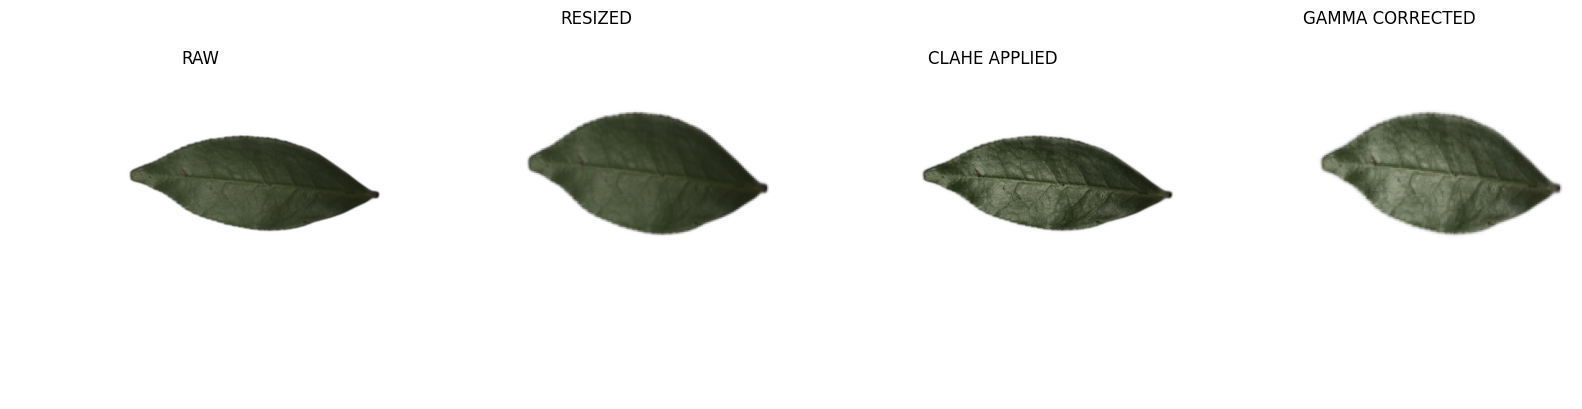

In [48]:
# Visualize full preprocessing pipeline step-by-step:
# RAW  →  RESIZED  →  CLAHE  →  GAMMA  (final)

import matplotlib.pyplot as plt
import cv2
import random

# --- pick a random raw image ---
random_class = random.choice(os.listdir(RAW_DIR))
raw_folder = os.path.join(RAW_DIR, random_class)
raw_image_path = os.path.join(raw_folder, random.choice(os.listdir(raw_folder)))

# --- load RAW image (BGR → RGB) ---
raw = cv2.cvtColor(cv2.imread(raw_image_path), cv2.COLOR_BGR2RGB)

# --- RESIZED ---
resized = resize_image(cv2.imread(raw_image_path))

# convert to RGB for display
resized = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

# --- CLAHE ---
clahe_img = apply_clahe_bgr(cv2.imread(raw_image_path))
clahe_img = cv2.cvtColor(clahe_img, cv2.COLOR_BGR2RGB)

# --- GAMMA ---
gamma_img = adjust_gamma(apply_clahe_bgr(resize_image(cv2.imread(raw_image_path))))
gamma_img = cv2.cvtColor(gamma_img, cv2.COLOR_BGR2RGB)

# --- plot all 4 ---
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(raw)
plt.title("RAW")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(resized)
plt.title("RESIZED")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(clahe_img)
plt.title("CLAHE APPLIED")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(gamma_img)
plt.title("GAMMA CORRECTED")
plt.axis("off")

plt.tight_layout()
plt.show()


In [13]:
# Cell 6 - Apply preprocessing to all splits and save to WORK_DIR/{split}/{class}/
def save_preprocessed(paths, labels, split_name):
    for p, lab in zip(paths, labels):
        out_dir = os.path.join(WORK_DIR, split_name, lab)
        os.makedirs(out_dir, exist_ok=True)
        filename = os.path.basename(p)
        out_path = os.path.join(out_dir, filename)
        try:
            img = preprocess_pipeline(p)  # RGB uint8
            # save as jpg (RGB->BGR for cv2)
            cv2.imwrite(out_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), 90])
        except Exception as e:
            print("Skipped:", p, "Error:", e)

# Preprocess and save (this may take time depending on dataset size)
save_preprocessed(train_paths, train_labels, "train")
save_preprocessed(val_paths, val_labels, "val")
save_preprocessed(test_paths, test_labels, "test")


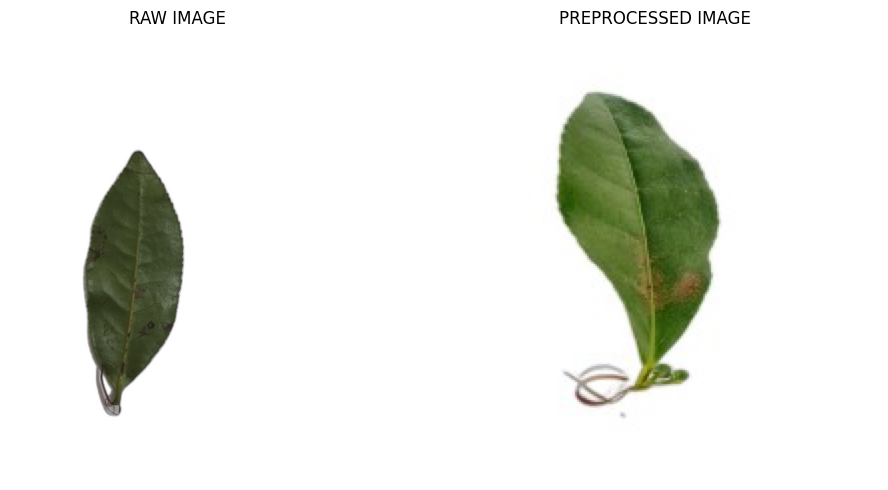

In [50]:
# Show before (raw) and after (preprocessed) images side-by-side
import matplotlib.pyplot as plt
import cv2
import random

# pick a random image from RAW_DIR
random_class = random.choice(os.listdir(RAW_DIR))
raw_folder = os.path.join(RAW_DIR, random_class)
raw_image_path = random.choice([os.path.join(raw_folder, f) for f in os.listdir(raw_folder)])

# corresponding preprocessed image path (same filename if exists)
pre_folder = os.path.join(WORK_DIR, "train", random_class)
preprocessed_candidates = [f for f in os.listdir(pre_folder) if os.path.splitext(f)[0] in raw_image_path]
if len(preprocessed_candidates) > 0:
    preprocessed_image_path = os.path.join(pre_folder, preprocessed_candidates[0])
else:
    # fallback: load first processed image from that class
    preprocessed_image_path = os.path.join(pre_folder, os.listdir(pre_folder)[0])

# load raw + processed
raw_img = cv2.cvtColor(cv2.imread(raw_image_path), cv2.COLOR_BGR2RGB)
proc_img = cv2.cvtColor(cv2.imread(preprocessed_image_path), cv2.COLOR_BGR2RGB)

# plot
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(raw_img)
plt.title("RAW IMAGE")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(proc_img)
plt.title("PREPROCESSED IMAGE")
plt.axis("off")

plt.tight_layout()
plt.show()


In [14]:
# Cell 7 - Create ImageDataGenerators
# Augmentation: apply only to training generator (as requested)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# For val/test: only rescale
test_val_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    os.path.join(WORK_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # change if using sparse
    shuffle=True
)

val_generator = test_val_datagen.flow_from_directory(
    os.path.join(WORK_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_val_datagen.flow_from_directory(
    os.path.join(WORK_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 2806 images belonging to 6 classes.
Found 601 images belonging to 6 classes.
Found 602 images belonging to 6 classes.


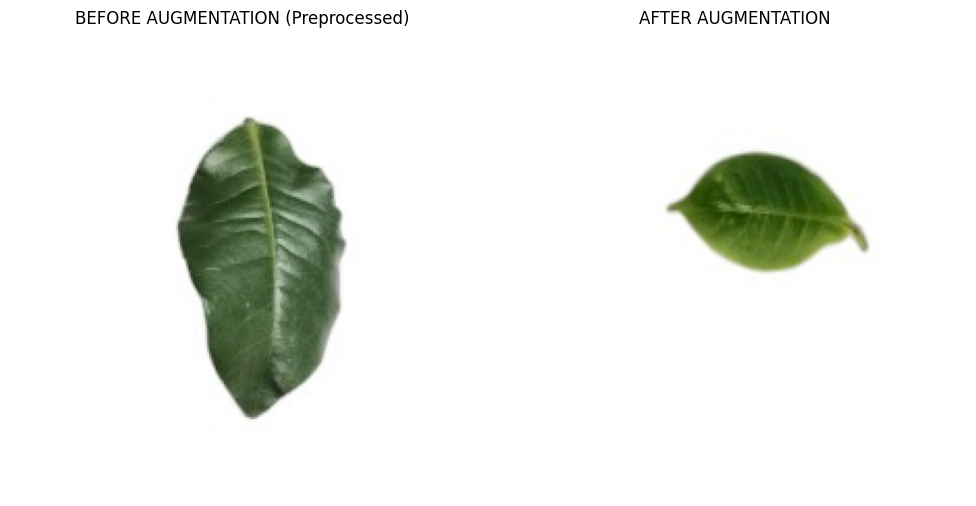

In [52]:
# SHOW BEFORE (ORIGINAL PREPROCESSED IMAGE) AND AFTER (AUGMENTED IMAGE)
# Place this cell RIGHT AFTER Cell 7 (the ImageDataGenerators cell)

import matplotlib.pyplot as plt
import numpy as np

# Get one batch from the training generator
imgs, labels = next(train_generator)

# pick a random image from the batch
idx = np.random.randint(0, imgs.shape[0])
augmented_img = imgs[idx]        # already augmented + rescaled
label = labels[idx]

# load the corresponding original preprocessed image (before augmentation)
# locate the class folder
class_index = np.argmax(label)
class_name = list(train_generator.class_indices.keys())[class_index]

# pick a random original preprocessed file from that class
preprocessed_folder = os.path.join(WORK_DIR, "train", class_name)
original_file = random.choice(os.listdir(preprocessed_folder))
original_path = os.path.join(preprocessed_folder, original_file)

# load original (RGB)
original_img = cv2.cvtColor(cv2.imread(original_path), cv2.COLOR_BGR2RGB) / 255.0

# plot before/after augmentation
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("BEFORE AUGMENTATION (Preprocessed)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(augmented_img)
plt.title("AFTER AUGMENTATION")
plt.axis("off")

plt.tight_layout()
plt.show()


In [15]:
# Cell 8 - Class balancing: compute class weights from training labels
# We compute using the filenames inside train folder to be robust
# FIX: create label encoder again from the TRAIN FOLDERS
# Put this cell BEFORE Cell 8 (or replace Cell 8 entirely)

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight

# Rebuild label encoder from the folder names inside WORK_DIR/train
class_names = sorted([
    d for d in os.listdir(os.path.join(WORK_DIR, "train"))
    if os.path.isdir(os.path.join(WORK_DIR, "train", d))
])

le = LabelEncoder()
le.fit(class_names)   # now 'le' is defined exactly as training generators expect

print("Classes:", le.classes_)

# Now compute class weights
train_classes = []
train_root = os.path.join(WORK_DIR, "train")

for cls_name in class_names:
    cls_dir = os.path.join(train_root, cls_name)
    file_count = len([
        f for f in os.listdir(cls_dir)
        if os.path.isfile(os.path.join(cls_dir, f))
    ])
    train_classes += [cls_name] * file_count

train_classes_encoded = le.transform(train_classes)

cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes_encoded),
    y=train_classes_encoded
)

class_weights = {i: float(cw[i]) for i in range(len(cw))}
print("Class weights:", class_weights)



Classes: ['Healthy' 'Heliopeltis' 'Red Rust' 'Red Spider' 'Sunlight Scorching'
 'Thrips']
Class weights: {0: 0.5363149847094801, 1: 2.3739424703891707, 2: 3.6253229974160206, 3: 1.6295005807200929, 4: 0.39037284362826935, 5: 3.8021680216802167}


In [61]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
import tensorflow as tf
import os

def build_and_train(base_model_class, preprocess_fn, model_name):
    tf.keras.backend.clear_session()

    # Generators
    train_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=25,
        width_shift_range=0.15,
        height_shift_range=0.15,
        zoom_range=0.20,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode='nearest'
    ).flow_from_directory(
        os.path.join(WORK_DIR, "train"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )

    val_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    ).flow_from_directory(
        os.path.join(WORK_DIR, "val"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    test_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    ).flow_from_directory(
        os.path.join(WORK_DIR, "test"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    # Base model
    base = base_model_class(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
    base.trainable = True
    for layer in base.layers[:-40]:
        layer.trainable = False

    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.45)(x)
    x = layers.Dense(256, activation="swish")(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(len(le.classes_), activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # SAFE SAVE PATHS (these WILL appear in Drive)
    BEST_PATH = f"/content/drive/MyDrive/{model_name}_best.keras"
    FINAL_PATH = f"/content/drive/MyDrive/{model_name}_final.keras"

    callbacks = [
        ModelCheckpoint(
            BEST_PATH,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.4,
            patience=3,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_accuracy",
            patience=7,
            restore_best_weights=True,
            verbose=1
        )
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    # Save final trained version
    model.save(FINAL_PATH)

    # Evaluate
    metrics = model.evaluate(test_gen, verbose=1)

    print(model_name, "BEST SAVED AT:", BEST_PATH)
    print(model_name, "FINAL SAVED AT:", FINAL_PATH)

    return history, metrics

In [62]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0, ResNet50V2, InceptionResNetV2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as enet_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as inceptionresnet_preprocess

# Cell: Run all 3 models (RUN THIS AFTER DEFINING build_and_train)

# 1) EfficientNetV2B0
hist_enet, metrics_enet = build_and_train(EfficientNetV2B0, enet_preprocess, "EfficientNetV2B0")
print("EffNetV2B0 test:", metrics_enet)

Found 2806 images belonging to 6 classes.
Found 601 images belonging to 6 classes.
Found 602 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.2972 - loss: 1.7211
Epoch 1: val_accuracy improved from -inf to 0.42263, saving model to /content/drive/MyDrive/EfficientNetV2B0_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 107s 828ms/step - accuracy: 0.2975 - loss: 1.7207 - val_accuracy: 0.4226 - val_loss: 1.4861 - learning_rate: 1.0000e-04
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.3993 - loss: 1.5412
Epoch 2: val_accuracy improved from 0.42263 to 0.48918, saving model to /content/drive/MyDrive/EfficientNetV2B0_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 44s 500ms/step - accuracy: 0.3994 - loss: 1.5408 - val_accuracy: 0.4892 - val_loss: 1.3370 - learning_rate: 1.0000e-04
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.4730 - loss: 1.3839
Epoch 3: val_accuracy improved from 0.48918 to 0.50915, saving model to /content/drive/MyDrive/EfficientNetV2B0_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 46s 517ms/step - accuracy: 0.4731 - loss: 1.3839 - val_a

In [63]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0, ResNet50V2, InceptionResNetV2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as enet_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as inceptionresnet_preprocess
# 2) ResNet50V2
hist_resnet, metrics_resnet = build_and_train(ResNet50V2, resnet_preprocess, "ResNet50V2")
print("ResNet50V2 test:", metrics_resnet)

Found 2806 images belonging to 6 classes.
Found 601 images belonging to 6 classes.
Found 602 images belonging to 6 classes.
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.3353 - loss: 1.7117
Epoch 1: val_accuracy improved from -inf to 0.45258, saving model to /content/drive/MyDrive/ResNet50V2_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 79s 681ms/step - accuracy: 0.3360 - loss: 1.7109 - val_accuracy: 0.4526 - val_loss: 1.6698 - learning_rate: 1.0000e-04
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.4633 - loss: 1.3674
Epoch 2: val_accuracy improved from 0.45258 to 0.53078, saving model to /content/drive/MyDrive/ResNet50V2_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 50s 561ms/step - accuracy: 0.4634 - loss: 1.3674 - val_accuracy: 0.5308 - val_loss: 1.5459 - learning_rate: 1.0000e-04
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.5194 - loss: 1.2929
Epoch 3: val_accuracy improved from 0.53078 to 0.59734, saving model to /content/drive/MyDrive/

In [64]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0, ResNet50V2, InceptionResNetV2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as enet_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as inceptionresnet_preprocess
# 3) InceptionResNetV2
hist_incepres, metrics_incepres = build_and_train(InceptionResNetV2, inceptionresnet_preprocess, "InceptionResNetV2")
print("InceptionResNetV2 test:", metrics_incepres)

Found 2806 images belonging to 6 classes.
Found 601 images belonging to 6 classes.
Found 602 images belonging to 6 classes.
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.2771 - loss: 1.7433
Epoch 1: val_accuracy improved from -inf to 0.47255, saving model to /content/drive/MyDrive/InceptionResNetV2_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 121s 969ms/step - accuracy: 0.2777 - loss: 1.7425 - val_accuracy: 0.4725 - val_loss: 1.4829 - learning_rate: 1.0000e-04
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.4576 - loss: 1.4064
Epoch 2: val_accuracy improved from 0.47255 to 0.49584, saving model to /content/drive/MyDrive/InceptionResNetV2_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 55s 627ms/step - accuracy: 0.4574 - loss: 1.4069 - val_accuracy: 0.4958 - val_loss: 1.2943 - learning_rate: 1.0000e-04
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.4873 - loss: 1.2786
Epoch 3: val_accuracy improved from 0.49584 to 0.51747, saving model to /content


Evaluating EfficientNetV2B0 ...
Found 602 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


EfficientNetV2B0  Acc=0.5266  Prec=0.6620  Rec=0.5266  F1=0.5604
                    precision    recall  f1-score   support

           Healthy       0.77      0.71      0.74       187
       Heliopeltis       0.26      0.45      0.33        42
          Red Rust       0.26      0.36      0.30        28
        Red Spider       0.29      0.31      0.30        62
Sunlight Scorching       0.83      0.46      0.59       257
            Thrips       0.18      0.77      0.29        26

          accuracy                           0.53       602
         macro avg       0.43      0.51      0.42       602
      weighted avg       0.66      0.53      0.56       602


Evaluating ResNet50V2 ...
Found 602 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


ResNet50V2  Acc=0.5864  Prec=0.6458  Rec=0.5864  F1=0.6036
                    precision    recall  f1-score   support

           Healthy       0.75      0.75      0.75       187
       Heliopeltis       0.28      0.19      0.23        42
          Red Rust       0.29      0.32      0.31        28
        Red Spider       0.28      0.31      0.29        62
Sunlight Scorching       0.81      0.61      0.69       257
            Thrips       0.21      0.73      0.33        26

          accuracy                           0.59       602
         macro avg       0.43      0.49      0.43       602
      weighted avg       0.65      0.59      0.60       602


Evaluating InceptionResNetV2 ...
Found 602 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


InceptionResNetV2  Acc=0.5432  Prec=0.6232  Rec=0.5432  F1=0.5656
                    precision    recall  f1-score   support

           Healthy       0.73      0.71      0.72       187
       Heliopeltis       0.22      0.62      0.32        42
          Red Rust       0.19      0.36      0.25        28
        Red Spider       0.29      0.23      0.25        62
Sunlight Scorching       0.78      0.54      0.64       257
            Thrips       0.25      0.19      0.22        26

          accuracy                           0.54       602
         macro avg       0.41      0.44      0.40       602
      weighted avg       0.62      0.54      0.57       602



/tmp/ipython-input-4275486268.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=45)
/tmp/ipython-input-4275486268.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=45)


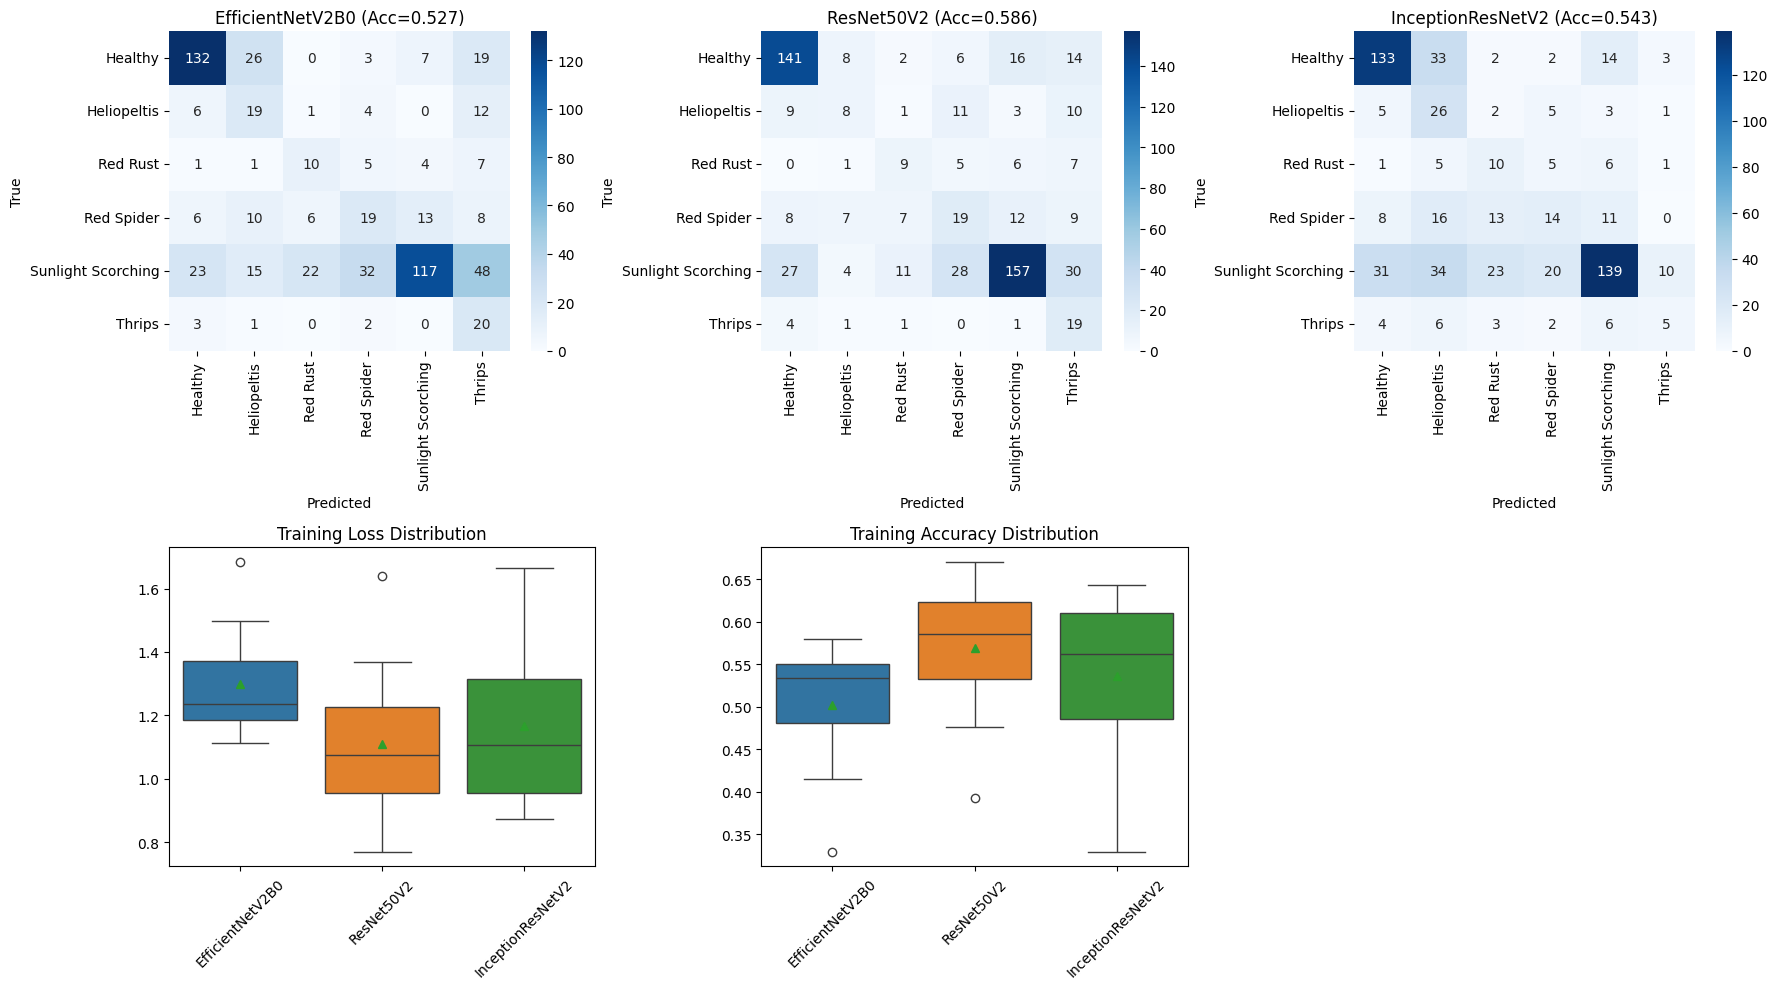


FINAL SUMMARY:
EfficientNetV2B0: ACC=0.5266, PREC=0.6620, REC=0.5266, F1=0.5604
ResNet50V2: ACC=0.5864, PREC=0.6458, REC=0.5864, F1=0.6036
InceptionResNetV2: ACC=0.5432, PREC=0.6232, REC=0.5432, F1=0.5656


In [65]:
# Cell: Evaluation + Confusion Matrix + Precision/Recall/F1 + Boxplots (FOR ALL 3 MODELS)
# RUN THIS **AFTER** TRAINING ALL 3 MODELS WITH YOUR build_and_train() CELL

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support

# model file paths (best saved models)
MODEL_FILES = {
    "EfficientNetV2B0": "/content/drive/MyDrive/EfficientNetV2B0_best.keras",
    "ResNet50V2": "/content/drive/MyDrive/ResNet50V2_best.keras",
    "InceptionResNetV2": "/content/drive/MyDrive/InceptionResNetV2_best.keras"
}

# correct preprocess functions
PREPROCESS_FUNCS = {
    "EfficientNetV2B0": enet_preprocess,
    "ResNet50V2": resnet_preprocess,
    "InceptionResNetV2": inceptionresnet_preprocess
}

def make_test_generator(preproc_fn):
    return ImageDataGenerator(
        preprocessing_function=preproc_fn
    ).flow_from_directory(
        os.path.join(WORK_DIR, "test"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

results = {}
history_map = {
    "EfficientNetV2B0": hist_enet.history,
    "ResNet50V2": hist_resnet.history,
    "InceptionResNetV2": hist_incepres.history
}

# evaluation loop
for name, path in MODEL_FILES.items():
    print(f"\nEvaluating {name} ...")

    model = load_model(path, compile=False)
    test_gen = make_test_generator(PREPROCESS_FUNCS[name])

    steps = max(1, int(np.ceil(test_gen.samples / test_gen.batch_size)))
    preds_prob = model.predict(test_gen, steps=steps, verbose=0)

    y_pred = np.argmax(preds_prob, axis=1)
    y_true = test_gen.classes
    class_names = list(test_gen.class_indices.keys())

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)
    cls_report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)

    results[name] = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "cm": cm,
        "report": cls_report,
        "history": history_map[name]
    }

    print(f"{name}  Acc={acc:.4f}  Prec={precision:.4f}  Rec={recall:.4f}  F1={f1:.4f}")
    print(cls_report)

# PLOT CONFUSION MATRICES + LOSS BOX + ACCURACY BOX
model_names = list(results.keys())
n = len(model_names)

plt.figure(figsize=(6*n, 10))

# Confusion matrices
for i, name in enumerate(model_names):
    ax = plt.subplot(2, n, i+1)
    sns.heatmap(results[name]["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{name} (Acc={results[name]['accuracy']:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

# Prepare boxplot data
loss_data = [results[name]["history"]["loss"] for name in model_names]
acc_data = [results[name]["history"]["accuracy"] for name in model_names]

# Loss boxplot
ax = plt.subplot(2, n, n+1)
sns.boxplot(data=loss_data, showmeans=True)
ax.set_xticklabels(model_names, rotation=45)
ax.set_title("Training Loss Distribution")

# Accuracy boxplot
ax = plt.subplot(2, n, n+2)
sns.boxplot(data=acc_data, showmeans=True)
ax.set_xticklabels(model_names, rotation=45)
ax.set_title("Training Accuracy Distribution")

plt.tight_layout()
plt.show()

# Summary metrics
print("\nFINAL SUMMARY:")
for name in model_names:
    r = results[name]
    print(f"{name}: ACC={r['accuracy']:.4f}, PREC={r['precision']:.4f}, REC={r['recall']:.4f}, F1={r['f1']:.4f}")


In [4]:
# RUN THIS BEFORE THE LIGHTWEIGHT CNN CELL
IMG_SIZE = (224, 224)     # or whatever size you used for big models
BATCH_SIZE = 32
WORK_DIR = "/content/processed_dataset"   # your dataset folder


In [16]:
# CELL: Build, fine-tune and train the custom lightweight ensemble CNN (5 epochs)
# Run this cell where your workspace has access to WORK_DIR, IMG_SIZE, BATCH_SIZE, class_weights, le, and Drive mounted.

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications import EfficientNetV2B0, ResNet50V2, InceptionResNetV2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as enet_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as inceptionresnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Settings
IMG_SHAPE = (*IMG_SIZE, 3)
NUM_CLASSES = len(le.classes_)
DROPOUT_RATE = 0.35
EPOCHS = 5

# Build model (Lambdas apply model-specific preprocessing internally)
inputs = layers.Input(shape=IMG_SHAPE, name="input_image")

enet_pre = layers.Lambda(lambda x: enet_preprocess(x), name="enet_preproc")(inputs)
resnet_pre = layers.Lambda(lambda x: resnet_preprocess(x), name="resnet_preproc")(inputs)
incep_pre = layers.Lambda(lambda x: inceptionresnet_preprocess(x), name="incep_preproc")(inputs)

enet_base = EfficientNetV2B0(include_top=False, weights="imagenet", input_shape=IMG_SHAPE)
resnet_base = ResNet50V2(include_top=False, weights="imagenet", input_shape=IMG_SHAPE)
incep_base = InceptionResNetV2(include_top=False, weights="imagenet", input_shape=IMG_SHAPE)

# enable limited fine-tuning
enet_base.trainable = True
for layer in enet_base.layers[:-30]:
    layer.trainable = False

resnet_base.trainable = True
for layer in resnet_base.layers[:-30]:
    layer.trainable = False

incep_base.trainable = True
for layer in incep_base.layers[:-50]:
    layer.trainable = False

feat_enet = enet_base(enet_pre, training=True)
feat_enet = layers.GlobalAveragePooling2D(name="gap_enet")(feat_enet)
feat_enet = layers.Dense(128, activation="swish", name="proj_enet")(feat_enet)

feat_resnet = resnet_base(resnet_pre, training=True)
feat_resnet = layers.GlobalAveragePooling2D(name="gap_resnet")(feat_resnet)
feat_resnet = layers.Dense(128, activation="swish", name="proj_resnet")(feat_resnet)

feat_incep = incep_base(incep_pre, training=True)
feat_incep = layers.GlobalAveragePooling2D(name="gap_incep")(feat_incep)
feat_incep = layers.Dense(128, activation="swish", name="proj_incep")(feat_incep)

concat = layers.Concatenate(name="concat_feats")([feat_enet, feat_resnet, feat_incep])
x = layers.BatchNormalization()(concat)
x = layers.Dropout(DROPOUT_RATE)(x)
x = layers.Dense(256, activation="swish")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

lightweight_ensemble = models.Model(inputs=inputs, outputs=outputs, name="lightweight_ensemble")
lightweight_ensemble.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                             loss="categorical_crossentropy",
                             metrics=["accuracy"])
lightweight_ensemble.summary()

# Data generators (plain, no preprocessing — Lambdas inside model handle it)
plain_train_gen = ImageDataGenerator().flow_from_directory(
    os.path.join(WORK_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)
plain_val_gen = ImageDataGenerator().flow_from_directory(
    os.path.join(WORK_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
plain_test_gen = ImageDataGenerator().flow_from_directory(
    os.path.join(WORK_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Callbacks & save paths
BEST_PATH = "/content/drive/MyDrive/lightweight_ensemble_best.keras"
FINAL_PATH = "/content/drive/MyDrive/lightweight_ensemble_final.keras"

callbacks = [
    ModelCheckpoint(BEST_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.4, patience=3, verbose=1),
    EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True, verbose=1)
]

# Train
history = lightweight_ensemble.fit(
    plain_train_gen,
    validation_data=plain_val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Save final model
lightweight_ensemble.save(FINAL_PATH)

# Evaluate on test
test_metrics = lightweight_ensemble.evaluate(plain_test_gen, verbose=1)
print("Lightweight ensemble test metrics:", test_metrics)

# Expose history variable for later plotting
lightweight_ensemble_history = history


Model: "lightweight_ensemble"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enet_preproc        │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_preproc      │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incep_preproc       │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 7, 7,      │  5,919,312 │ enet_preproc[0][… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50v2          │ (None, 7, 7,      │ 23,564,800 │ resnet_preproc[0… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_resnet_v2 │ (None, 5, 5,      │ 54,336,736 │ incep_preproc[0]… │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap_enet            │ (None, 1280)      │          0 │ efficientnetv2-b… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap_resnet          │ (None, 2048)      │          0 │ resnet50v2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap_incep           │ (None, 1536)      │          0 │ inception_resnet… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_enet (Dense)   │ (None, 128)       │    163,968 │ gap_enet[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_resnet (Dense) │ (None, 128)       │    262,272 │ gap_resnet[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_incep (Dense)  │ (None, 128)       │    196,736 │ gap_incep[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_feats        │ (None, 384)       │          0 │ proj_enet[0][0],  │
│ (Concatenate)       │                   │            │ proj_resnet[0][0… │
│                     │                   │            │ proj_incep[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384)       │      1,536 │ concat_feats[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     98,560 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 84,546,486 (322.52 MB)

 Trainable params: 25,631,846 (97.78 MB)

 Non-trainable params: 58,914,640 (224.74 MB)

Found 2806 images belonging to 6 classes.
Found 601 images belonging to 6 classes.
Found 602 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.1726 - loss: 2.6744
Epoch 1: val_accuracy improved from -inf to 0.34942, saving model to /content/drive/MyDrive/lightweight_ensemble_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.1729 - loss: 2.6729 - val_accuracy: 0.3494 - val_loss: 1.6327 - learning_rate: 1.0000e-05
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.3123 - loss: 1.8776
Epoch 2: val_accuracy improved from 0.34942 to 0.45092, saving model to /content/drive/MyDrive/lightweight_ensemble_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 595ms/step - accuracy: 0.3125 - loss: 1.8777 - val_accuracy: 0.4509 - val_loss: 1.4869 - learning_rate: 1.0000e-05
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.3729 - loss: 1.5941
Epoch 3: val_accuracy improved from 0.45092 to 0.48087, saving model to /content/drive/MyDrive/lightweight_ensemble_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 533ms/step - accuracy: 0.3730 - loss: 1.5943 -

In [19]:
import keras
keras.config.enable_unsafe_deserialization()


Found 602 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step
Accuracy: 0.4700996677740864
Precision: 0.640806966220538
Recall: 0.4700996677740864
F1-score: 0.5191935350115566

Classification Report:
                     precision    recall  f1-score   support

           Healthy       0.78      0.65      0.71       187
       Heliopeltis       0.27      0.48      0.34        42
          Red Rust       0.11      0.36      0.17        28
        Red Spider       0.24      0.24      0.24        62
Sunlight Scorching       0.81      0.42      0.55       257
            Thrips       0.11      0.35      0.16        26

          accuracy                           0.47       602
         macro avg       0.39      0.41      0.36       602
      weighted avg       0.64      0.47      0.52       602



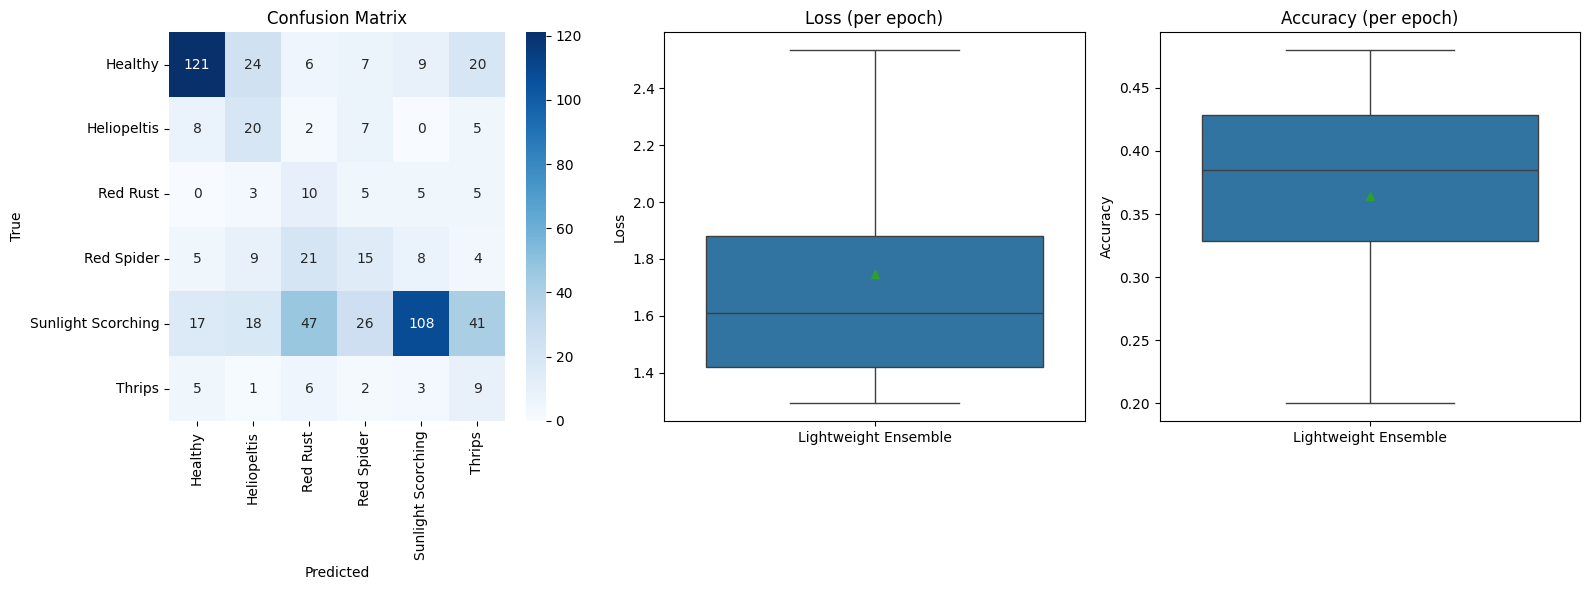

In [21]:
# Run this cell AFTER you train the lightweight_ensemble in the same notebook session
# (i.e., after the cell that created/trained 'lightweight_ensemble' and saved it).
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import tensorflow as tf

# Ensure preprocessing functions exist (Lambda layers in model may reference these)
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as enet_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as inceptionresnet_preprocess

# Try to use model in memory first, otherwise try loading (unsafe) from DRIVE path
MODEL_PATH = "/content/drive/MyDrive/lightweight_ensemble_final.keras"

if 'lightweight_ensemble' in globals():
    model = lightweight_ensemble
else:
    # enable unsafe deserialization to allow Lambda layers (only if you trust the file)
    tf.keras.backend.clear_session()
    from tensorflow import keras
    keras.config.enable_unsafe_deserialization()
    try:
        model = load_model(MODEL_PATH, compile=False)
    except Exception as e:
        raise RuntimeError(f"Could not load model from disk. Train the model in this session first or ensure file exists: {MODEL_PATH}\nInner error: {e}")

# Build test generator (model expects raw images; Lambdas inside model will preprocess)
plain_test_gen = ImageDataGenerator().flow_from_directory(
    os.path.join(WORK_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

STEPS = max(1, int(np.ceil(plain_test_gen.samples / plain_test_gen.batch_size)))

# Predict
preds_prob = model.predict(plain_test_gen, steps=STEPS, verbose=1)
y_pred = np.argmax(preds_prob, axis=1)
y_true = plain_test_gen.classes
class_names = list(plain_test_gen.class_indices.keys())

# Metrics
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("\nClassification Report:\n", report)

# Get training history if available
if 'lightweight_ensemble_history' in globals():
    hist = lightweight_ensemble_history.history
else:
    # fallback: use model.evaluate loss as single-point history
    loss_val = model.evaluate(plain_test_gen, steps=STEPS, verbose=0)[0]
    hist = {"loss": [loss_val]*5, "accuracy": [acc]*5}

# Plots: confusion matrix + boxplots for loss & accuracy
plt.figure(figsize=(16,6))

plt.subplot(1,3,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.subplot(1,3,2)
sns.boxplot(data=[hist["loss"]], showmeans=True)
plt.xticks([0], ["Lightweight Ensemble"])
plt.title("Loss (per epoch)")
plt.ylabel("Loss")

plt.subplot(1,3,3)
sns.boxplot(data=[hist["accuracy"]], showmeans=True)
plt.xticks([0], ["Lightweight Ensemble"])
plt.title("Accuracy (per epoch)")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()


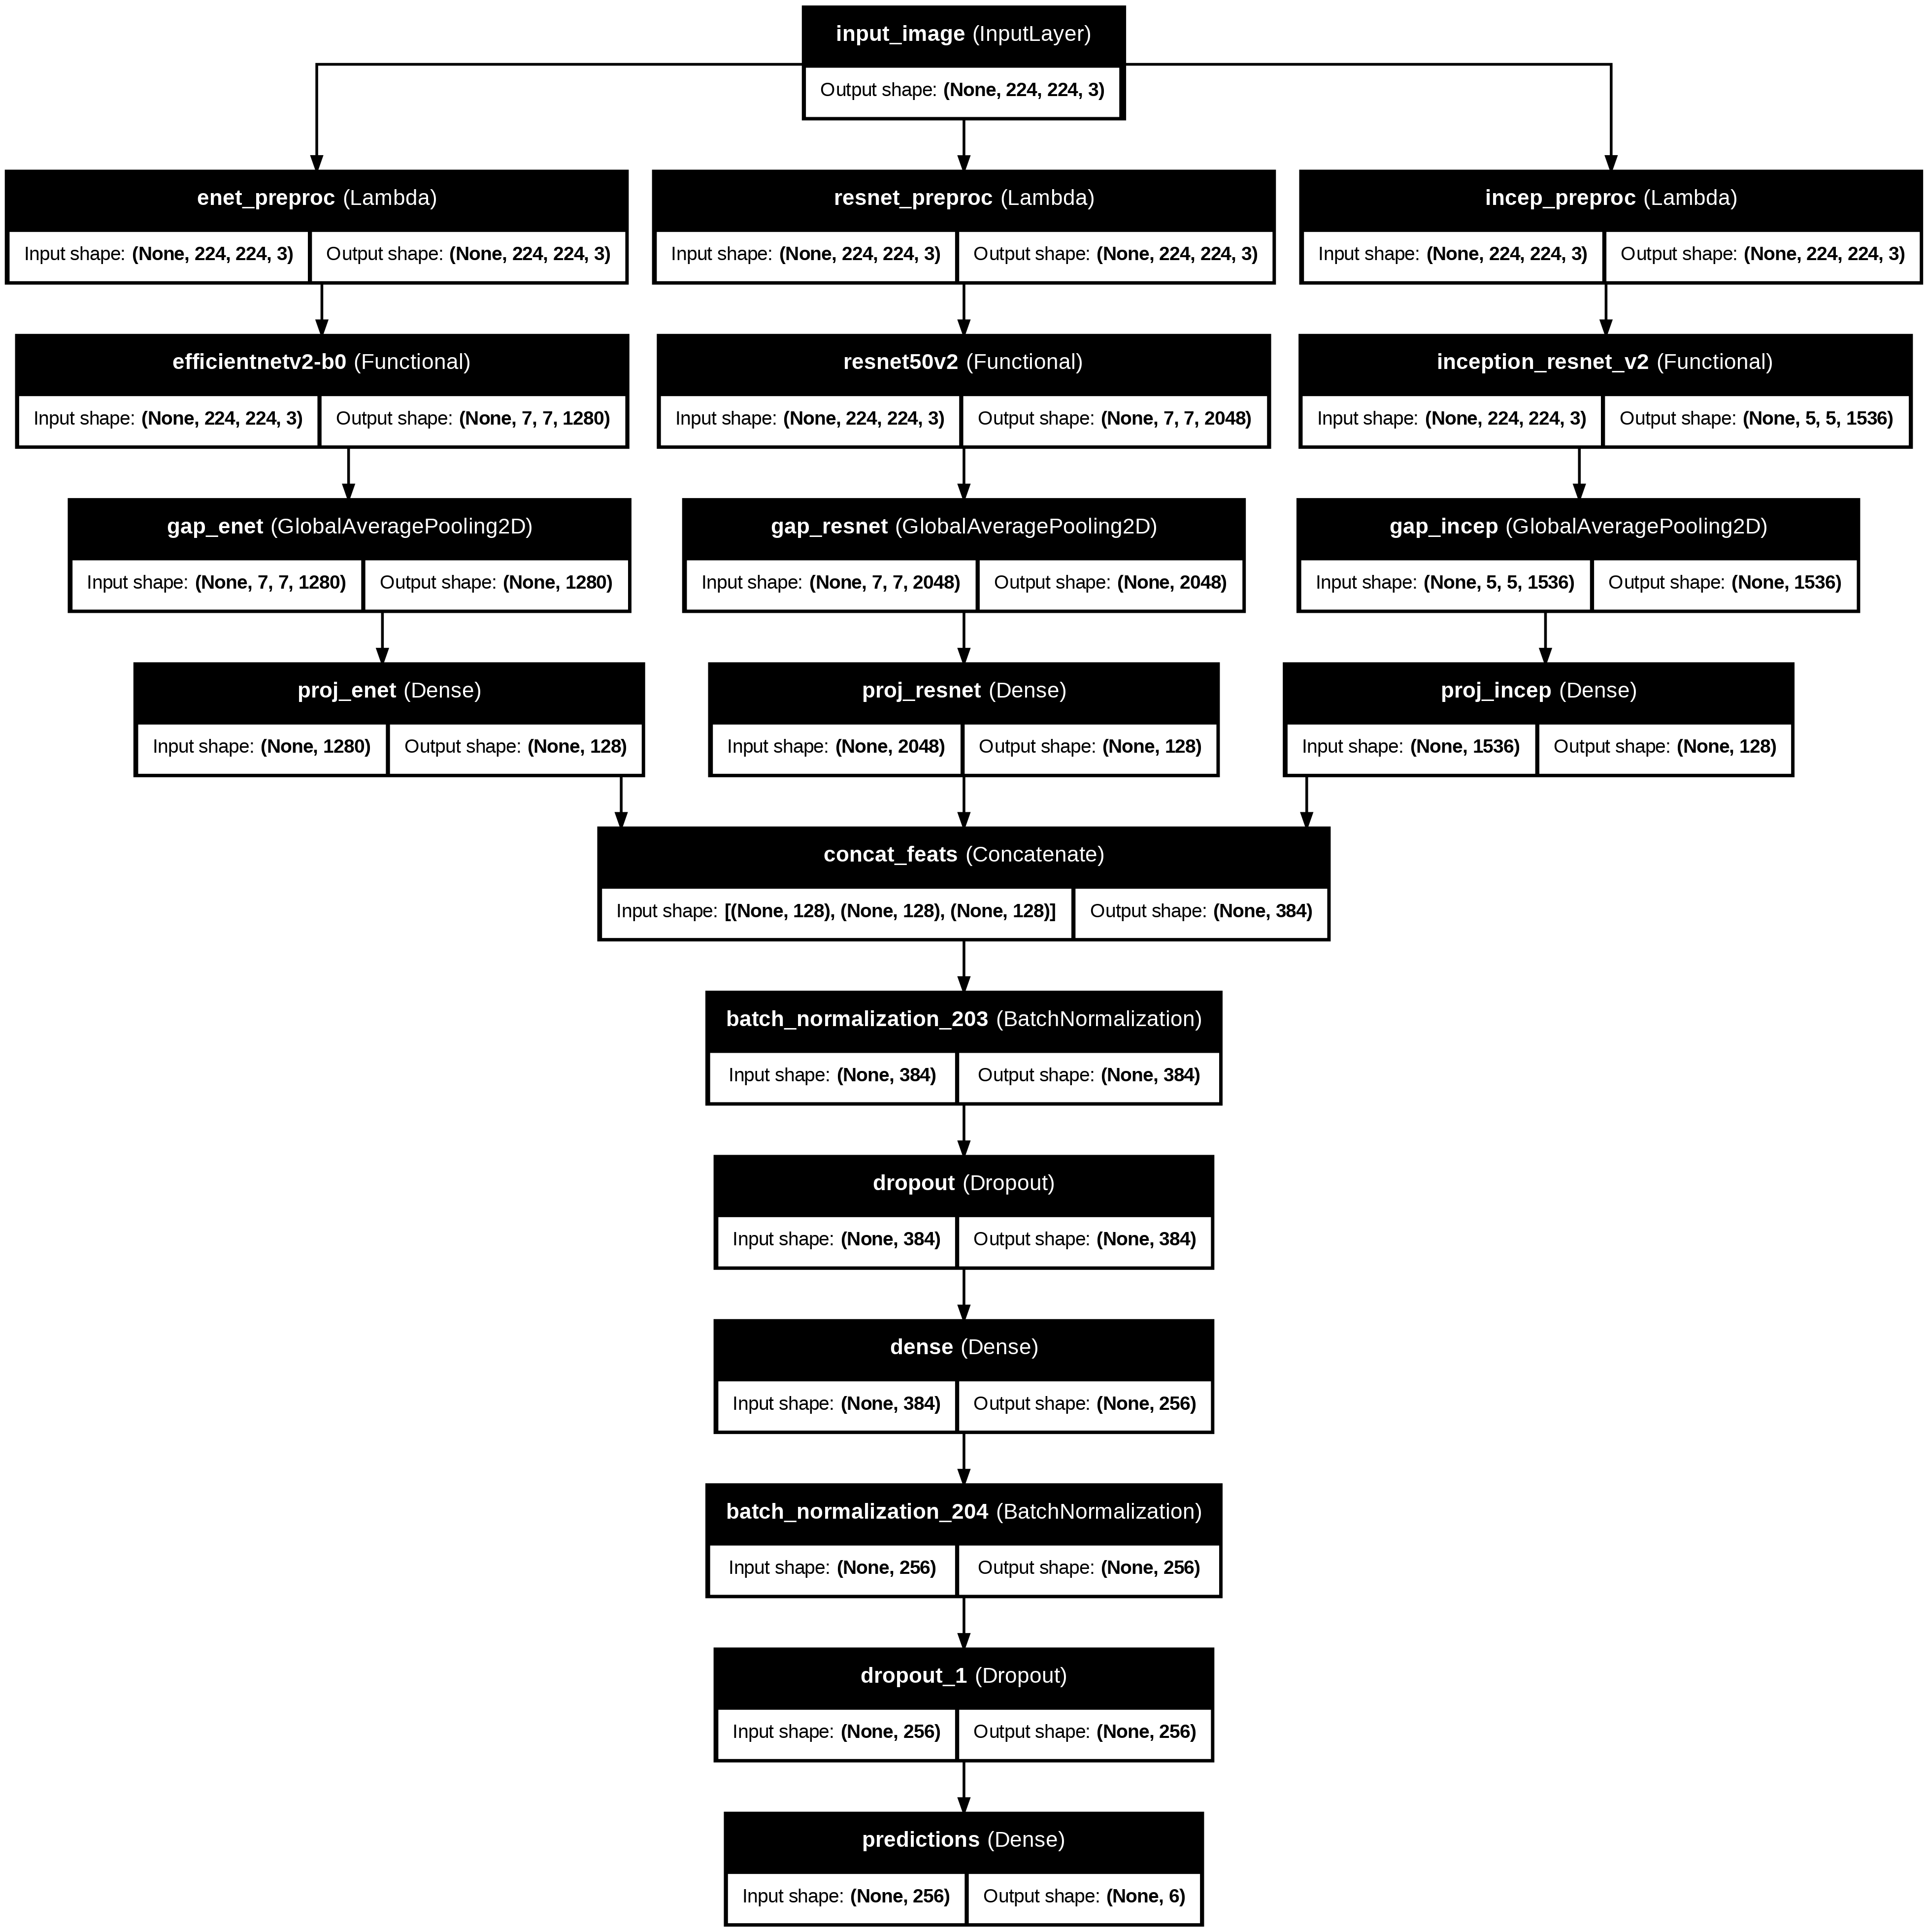

In [23]:
# Cell: Plot Lightweight Ensemble CNN Architecture (SHOW in output)

from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

PLOT_PATH = "/content/drive/MyDrive/lightweight_ensemble_architecture.png"

# Save architecture figure
plot_model(
    lightweight_ensemble,
    to_file=PLOT_PATH,
    show_shapes=True,
    show_layer_names=True,
    dpi=200
)

# Display inside notebook
display(Image(filename=PLOT_PATH))
